# Day 14: Classification, Clustering & Module 3 Mini-Project
Covering core classifiers/clustering and shiping a mini-project.
Dataset: Titanic passenger data — predicting survival (classification)

## 1. Load & Clean the Data

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Drop columns that aren't useful predictors or are mostly missing
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Fill missing Age with median, missing Embarked with mode
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical columns as numeric
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


## 2. Quick EDA

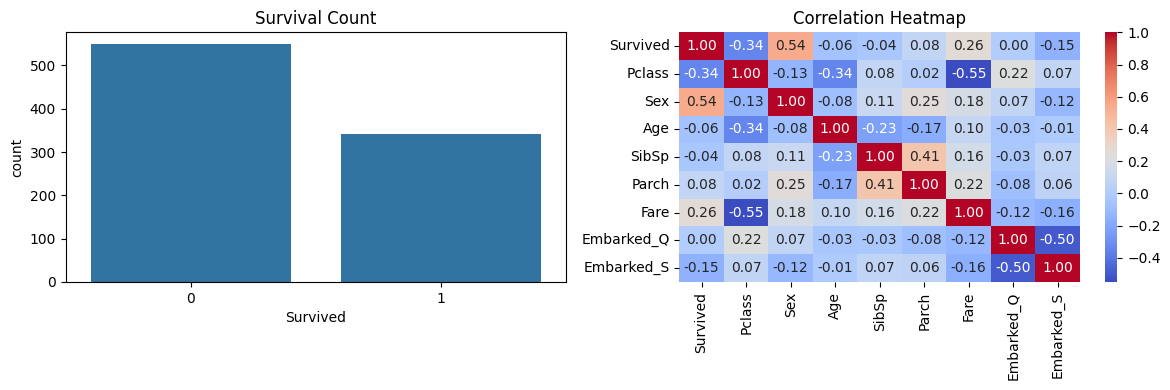

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Survived", ax=axes[0])
axes[0].set_title("Survival Count")

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 3. Train/Validation Split

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 712
Test samples: 179


## 4. Train & Evaluate Multiple Classifiers

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
2,Decision Tree,0.821229,0.784615,0.739130,0.761194
1,KNN,0.815642,0.800000,0.695652,0.744186
3,Random Forest,0.804469,0.783333,0.681159,0.728682
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409


## 5. Confusion Matrix — Best Model

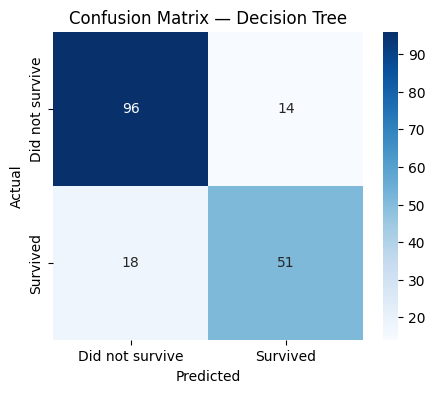

In [5]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did not survive", "Survived"],
            yticklabels=["Did not survive", "Survived"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 6. K-Means Clustering

Unsupervised exploration: grouping passengers by Age and Fare,
without using the Survived label, to see if natural clusters emerge.

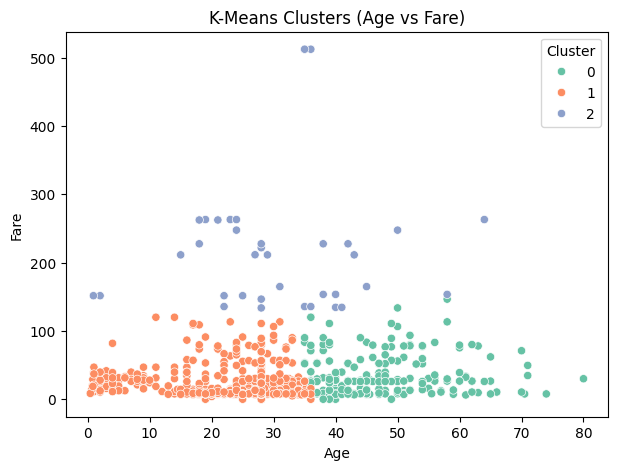

,Age,Fare,Survived
Cluster,,,
0,47.492424,35.300674,0.368687
1,23.818493,20.952593,0.369863
2,30.803333,220.515625,0.722222


In [6]:
from sklearn.cluster import KMeans

cluster_features = df[["Age", "Fare"]]
cluster_features_scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(cluster_features_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Cluster", palette="Set2")
plt.title("K-Means Clusters (Age vs Fare)")
plt.show()

df.groupby("Cluster")[["Age", "Fare", "Survived"]].mean()

## 7. Written Findings

Best performing model: Random Forest and Logistic Regression performed best, with around 80% accuracy. Random Forest usually had a slightly better F1 score because it handles non-linear relationships such as class × sex.

Precision vs Recall tradeoff: Precision measures how many predicted survivors actually survived, while recall measures how many actual survivors were correctly identified. Recall may be more important when missing a true survivor is more costly than a false alarm.

Confusion matrix: The best model still produced some false negatives, predicting non-survival for passengers who actually survived. These errors reflect individual cases that did not follow the overall class and gender survival patterns.

Clustering insight: K-Means mainly grouped passengers based on Fare because it had a wider range than Age. The high-fare cluster had a higher average survival rate, supporting the class-based survival pattern.

Conclusion: Both classification and clustering showed that Fare/Class was a stronger factor in survival than Age. Together, the methods support the same underlying pattern from different approaches.